# 01 — Base diaria, tendencias recientes y EDA

Entradas: limpiezas oficiales de producción y clima; panel de 10 para conciliar cantidades. Unidad: GAITANA/producto/color/variedad/día. Se agregan movimientos legítimos sin deduplicarlos nuevamente. Un día sin registro permanece NaN; se distingue de un cero reportado. Las ventanas son días de calendario anteriores al origen, no últimas filas disponibles. Disponibilidad supuesta al día siguiente, por confirmar con la empresa.

Salidas fijas en `Datos_analiticos_proyecto/modelo_diario`: `produccion_clima_diaria.parquet` y `features_diarias.parquet`. El calendario completo no implica actividad continua de cada variedad. Este notebook sustituye la auditoría dependiente de CSV y variables ocultas.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'Datos_analiticos_proyecto').is_dir())
DATOS=ROOT/'Datos_analiticos_proyecto'
SALIDA=DATOS/'modelo_diario'
SALIDA.mkdir(exist_ok=True)
KEY=['finca','producto','color','variedad']
pd.set_option('display.max_columns',30)


## 1. Agregación y reconciliación con la base semanal

In [2]:
r=pd.read_parquet(DATOS/'produccion_real_limpio.parquet',columns=KEY+['fecha_corte','semana_inicio','tallos','llave_completa'])
r=r.loc[r.finca.eq('GAITANA')&r.semana_inicio.ge('2021-01-01')].copy()
assert r.llave_completa.all() and r.fecha_corte.notna().all() and r.tallos.notna().all() and r.tallos.ge(0).all()
r['fecha']=r.fecha_corte.dt.normalize().astype('datetime64[ns]')
assert r.semana_inicio.eq(r.fecha-pd.to_timedelta(r.fecha.dt.dayofweek,unit='D')).all()
diario=r.groupby(KEY+['fecha'],as_index=False).agg(tallos=('tallos','sum'),movimientos=('tallos','size'))
assert diario.tallos.sum()==r.tallos.sum()
diario['semana_inicio']=diario.fecha-pd.to_timedelta(diario.fecha.dt.dayofweek,unit='D')
recon=diario.groupby(KEY+['semana_inicio'],as_index=False).tallos.sum()
semanal=pd.read_parquet(DATOS/'modelo_con_proyecciones_teoricas'/'produccion_clima_semanal.parquet')
v=semanal[KEY+['semana_inicio','tallos_reales']].merge(recon,on=KEY+['semana_inicio'],how='outer',validate='one_to_one',indicator=True)
assert v._merge.eq('both').all() and v.tallos_reales.eq(v.tallos).all()
print('Movimientos:',len(r),'días-serie observados:',len(diario),'tallos:',int(r.tallos.sum()))
print('Reconciliación semanal por llave: cero diferencias.')
cal=pd.DataFrame({'fecha':pd.date_range(diario.fecha.min(),diario.fecha.max()+pd.Timedelta(days=2),freq='D')})
panel=diario[KEY].drop_duplicates().merge(cal,how='cross').merge(diario.drop(columns='semana_inicio'),on=KEY+['fecha'],how='left',validate='one_to_one')
panel['observado']=panel.tallos.notna();panel['dia_semana']=panel.fecha.dt.dayofweek
panel['semana_inicio']=panel.fecha-pd.to_timedelta(panel.dia_semana,unit='D')
del r


Movimientos: 4654552 días-serie observados: 227623 tallos: 327991200
Reconciliación semanal por llave: cero diferencias.


## 2. Clima diario y cobertura

Promedios de mediciones válidas, acompañados de su número. No se suman magnitudes sin unidades verificadas. Las variables predictivas usan exclusivamente fechas anteriores al origen.

In [3]:
c=pd.read_parquet(DATOS/'clima_limpio.parquet')
c=c.loc[c.finca.eq('GAITANA')&c.medicion_valida].copy()
c['fecha']=pd.to_datetime(c.fecha).dt.normalize().astype('datetime64[ns]')
clima=c.groupby(['finca','fecha'],as_index=False).agg(temperatura=('temperatura','mean'),humedad=('humedad','mean'),radiacion=('radiacion','mean'),mediciones_clima=('instante','size'))
panel=panel.merge(clima,on=['finca','fecha'],how='left',validate='many_to_one')
assert panel.tallos.sum()==diario.tallos.sum()
clima_cal=cal.merge(clima.drop(columns='finca'),on='fecha',how='left',validate='one_to_one').sort_values('fecha')
clima_features=['fecha']
for col in ['temperatura','humedad','radiacion']:
    for ventana in [3,5,7]:
        nombre=f'{col}_media_{ventana}d'
        clima_cal[nombre]=clima_cal[col].shift(1).rolling(ventana,min_periods=2).mean();clima_features.append(nombre)


## 3. Ventanas móviles y prueba temporal

Sumas del corte reportado en 3/5/7/14 días, medias, dispersión, EMA y tendencias. Cada ventana incluye conteo de observaciones. Una ventana sin observaciones queda faltante; la antigüedad advierte historia desactualizada.

In [4]:
def construir_features_diarias(panel):
    d=panel.sort_values(KEY+['fecha']).copy()
    g=d.groupby(KEY,sort=False).tallos
    for ventana in [3,5,7,14]:
        d[f'corte_media_{ventana}d']=g.transform(lambda s:s.shift(1).rolling(ventana,min_periods=1).mean())
        d[f'corte_suma_{ventana}d']=g.transform(lambda s:s.shift(1).rolling(ventana,min_periods=1).sum())
        d[f'corte_dias_{ventana}d']=g.transform(lambda s:s.shift(1).rolling(ventana,min_periods=1).count())
    d['corte_std_7d']=g.transform(lambda s:s.shift(1).rolling(7,min_periods=2).std())
    d['corte_lag1d']=g.shift(1);d['corte_lag7d']=g.shift(7)
    d['corte_ema_5d']=g.transform(lambda s:s.shift(1).ewm(span=5,adjust=False,min_periods=2).mean())
    for ventana in [3,5]:
        anterior=g.transform(lambda s:s.shift(ventana+1).rolling(ventana,min_periods=1).mean())
        d[f'corte_tendencia_{ventana}d']=d[f'corte_media_{ventana}d']-anterior
    ultima=d.fecha.where(d.tallos.notna()).groupby([d[c] for c in KEY],sort=False).transform(lambda s:s.ffill().shift(1))
    d['dias_desde_corte']=(d.fecha-ultima).dt.days
    return d

f=construir_features_diarias(panel[KEY+['fecha','tallos']])
f=f.merge(clima_cal[clima_features],on='fecha',how='left',validate='many_to_one')
columnas_diarias=[c for c in f if c.startswith('corte_') or c=='dias_desde_corte' or '_media_' in c]
f=f[KEY+['fecha']+columnas_diarias]
for c in columnas_diarias:f[c]=f[c].astype(np.float32)
assert not f.duplicated(KEY+['fecha']).any()
claves=diario[KEY].drop_duplicates().head(2)
m=panel.merge(claves,on=KEY,validate='many_to_one')[KEY+['fecha','tallos']]
corte=pd.Timestamp('2026-01-05');z=m.copy();z.loc[z.fecha.ge(corte),'tallos']=999999
a=construir_features_diarias(m);b=construir_features_diarias(z);cols=[c for c in a if c!='tallos']
pd.testing.assert_frame_equal(a.loc[a.fecha.le(corte),cols].reset_index(drop=True),b.loc[b.fecha.le(corte),cols].reset_index(drop=True))
print('Prueba temporal: correcta.')
panel.to_parquet(SALIDA/'produccion_clima_diaria.parquet',index=False)
f.to_parquet(SALIDA/'features_diarias.parquet',index=False)
display(f.loc[f.fecha.dt.dayofweek.eq(0),columnas_diarias].isna().mean().mul(100).to_frame('faltantes_pct_en_lunes'))


Prueba temporal: correcta.


,faltantes_pct_en_lunes
corte_media_3d,78.976797
corte_suma_3d,78.976797
corte_dias_3d,0.000000
corte_media_5d,78.119557
corte_suma_5d,78.119557
corte_dias_5d,0.000000
corte_media_7d,77.627964
corte_suma_7d,77.627964
corte_dias_7d,0.000000
corte_media_14d,76.690992


## 4. EDA: calendario, corte y asociaciones

Participación describe volumen registrado; presencia de reporte no equivale a producción física positiva. Las asociaciones se exploran antes de 2025-07-07 y se calculan dentro de las series para evitar confundir diferencias de escala con persistencia.

,dias_serie,observados,tallos,mediana_observada,pct_reporte,participacion_tallos_pct
dia_semana,,,,,,
0,196911,37104,50883604,610.0,18.843031,15.51371
1,196248,37738,50872083,607.5,19.229750,15.510198
2,196248,37450,50717798,615.0,19.082997,15.463158
3,196248,37023,50206007,615.0,18.865415,15.30712
4,196248,37379,56121112,676.0,19.046818,17.110554
5,196248,38032,65539140,770.0,19.379561,19.981981
6,196248,2897,3651456,632.0,1.476193,1.113279


,dias,registros,tallos
fecha,,,
2021,314,36015,53230988
2022,310,39048,48848530
2023,314,43670,57341913
2024,313,38996,58946279
2025,316,41560,61592547
2026,210,28334,48030943


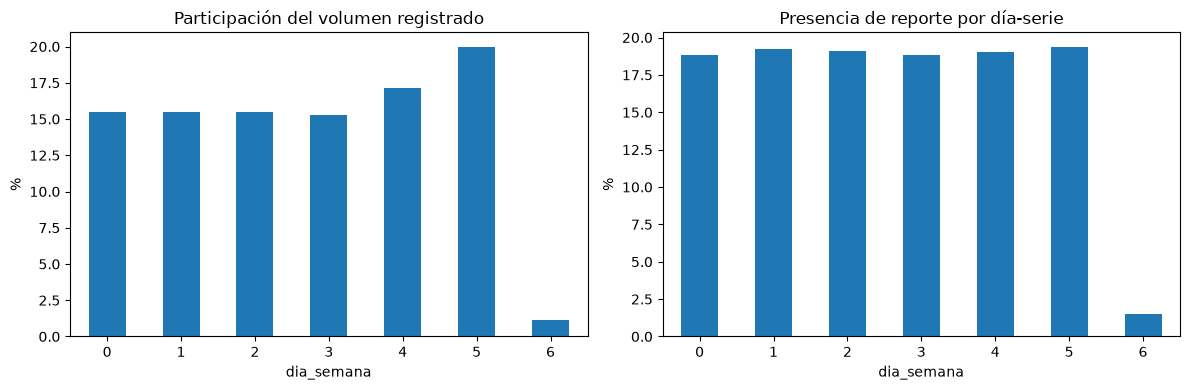

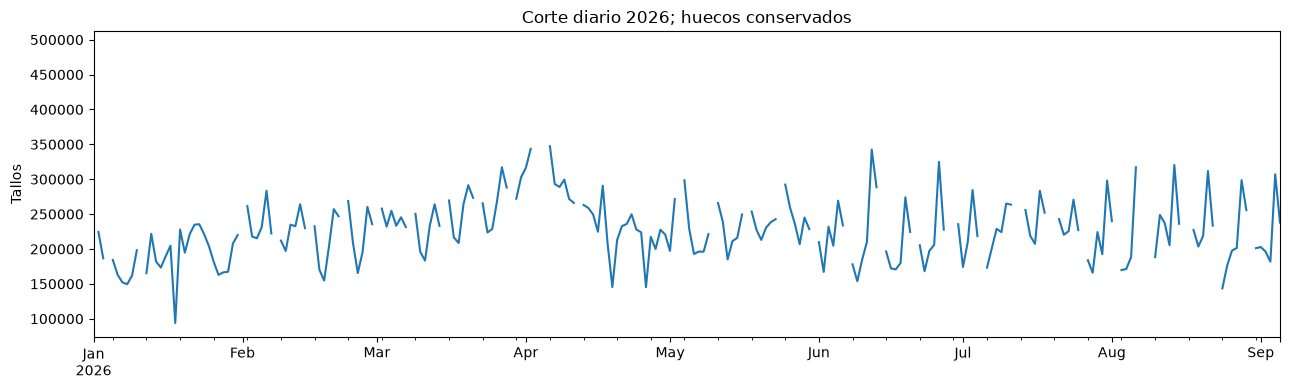

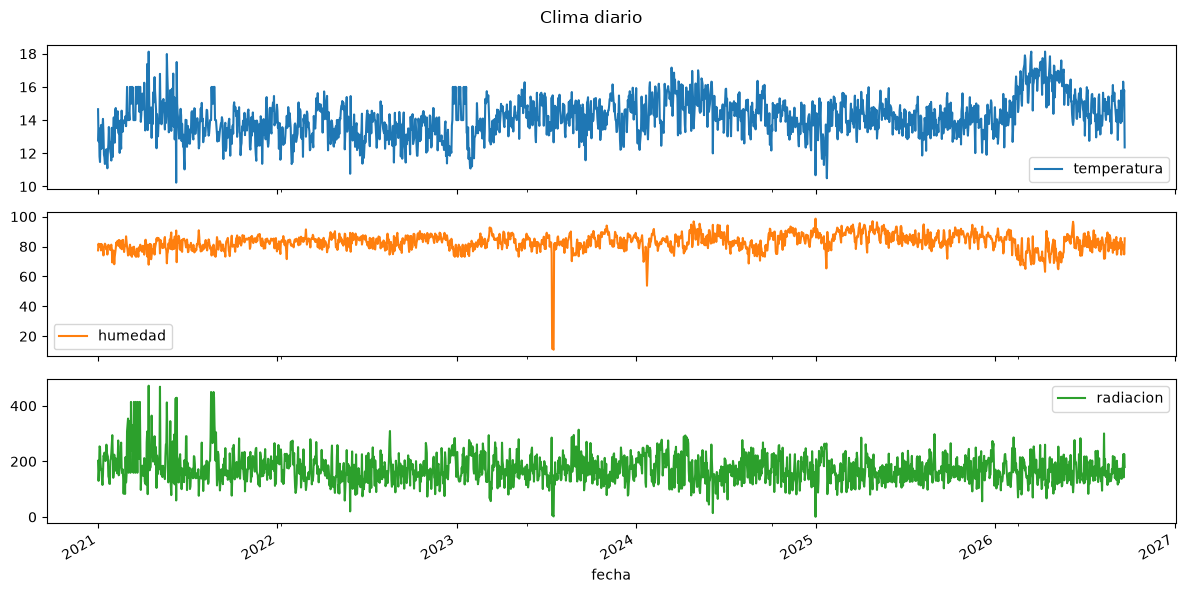

,series,rho_mediana,q25,q75
variable,,,,
corte_ema_5d,341,0.660327,0.492774,0.771803
corte_media_3d,305,0.639978,0.517377,0.751384
corte_media_5d,326,0.653459,0.497218,0.763787
corte_tendencia_3d,282,0.007114,-0.026734,0.048472
temperatura_media_5d,343,0.060619,-0.059019,0.220092


Domingo sin reporte no demuestra producción cero. Evaluar sólo sobre targets observados e informar cobertura.


In [5]:
perfil=panel.groupby('dia_semana').agg(dias_serie=('fecha','size'),observados=('observado','sum'),tallos=('tallos','sum'),mediana_observada=('tallos','median'))
perfil['pct_reporte']=100*perfil.observados/perfil.dias_serie
perfil['participacion_tallos_pct']=100*perfil.tallos/perfil.tallos.sum()
display(perfil)
display(diario.groupby(diario.fecha.dt.year).agg(dias=('fecha','nunique'),registros=('tallos','size'),tallos=('tallos','sum')))
fig,ax=plt.subplots(1,2,figsize=(12,4))
perfil.participacion_tallos_pct.plot.bar(ax=ax[0],title='Participación del volumen registrado',ylabel='%',rot=0)
perfil.pct_reporte.plot.bar(ax=ax[1],title='Presencia de reporte por día-serie',ylabel='%',rot=0)
plt.tight_layout();plt.show()
total=diario.groupby('fecha').tallos.sum().reindex(pd.date_range(diario.fecha.min(),diario.fecha.max()))
total.loc['2026'].plot(figsize=(13,4),title='Corte diario 2026; huecos conservados',ylabel='Tallos');plt.tight_layout();plt.show()
clima.set_index('fecha')[['temperatura','humedad','radiacion']].plot(subplots=True,figsize=(12,6),title='Clima diario');plt.tight_layout();plt.show()
e=panel.loc[panel.fecha.lt('2025-07-07')].merge(f,on=KEY+['fecha'],how='left',validate='one_to_one')
rel=[]
for clave,g in e.groupby(KEY):
    for col in ['corte_media_3d','corte_media_5d','corte_ema_5d','corte_tendencia_3d','temperatura_media_5d']:
        t=g[[col,'tallos']].dropna()
        if len(t)>=60 and t[col].nunique()>1 and t.tallos.nunique()>1:rel.append({'variable':col,'rho':t[col].corr(t.tallos,method='spearman'),'pares':len(t)})
rel=pd.DataFrame(rel)
display(rel.groupby('variable').agg(series=('rho','size'),rho_mediana=('rho','median'),q25=('rho',lambda s:s.quantile(.25)),q75=('rho',lambda s:s.quantile(.75))))
print('Domingo sin reporte no demuestra producción cero. Evaluar sólo sobre targets observados e informar cobertura.')


## 5. ¿Qué señal diaria puede ayudar al error semanal?

Se relacionan ventanas diarias conocidas al origen con real semanal menos media4, dentro de cada serie y horizonte, usando únicamente objetivos cerrados antes del primer corte. Se requiere soporte de 20 pares y se informa el número de series.

series  rho_mediana
horizonte variable                               
1.0       corte_ema_5d           246     0.077922
          corte_media_3d         229     0.121396
          corte_media_5d         240     0.097778
          corte_tendencia_3d     223     0.170673
          corte_tendencia_5d     236     0.377805
3.0       corte_ema_5d           226    -0.172316
          corte_media_3d         218    -0.130877
          corte_media_5d         224    -0.159336
          corte_tendencia_3d     215     0.067860
          corte_tendencia_5d     222     0.295343
5.0       corte_ema_5d           224    -0.302922
          corte_media_3d         215    -0.261046
          corte_media_5d         222    -0.288715
          corte_tendencia_3d     214     0.011709
          corte_tendencia_5d     218     0.208037

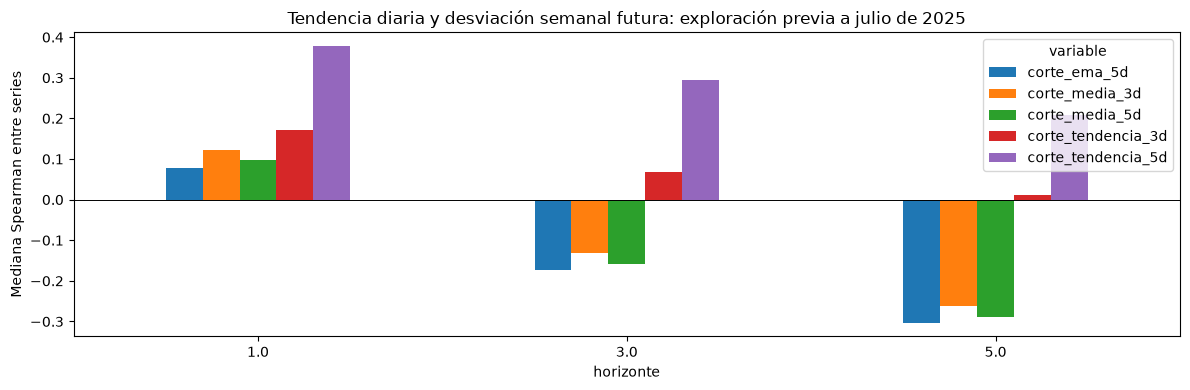

Una correlación con la desviación no demuestra mejora predictiva ni causalidad. El notebook 14 prueba el aporte fuera del entrenamiento.


In [6]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'Datos_analiticos_proyecto').is_dir())
KEY=['finca','producto','color','variedad']
f=pd.read_parquet(ROOT/'Datos_analiticos_proyecto/modelo_diario/features_diarias.parquet').rename(columns={'fecha':'origen'})
w=pd.read_parquet(ROOT/'Datos_analiticos_proyecto/modelo_con_proyecciones_teoricas/base_analitica_proyecciones.parquet')
w=w.loc[(w.semana_objetivo+pd.Timedelta(days=7)).le(pd.Timestamp('2025-07-07'))&w.y.notna()&w.horizonte.isin([1,3,5])].merge(f,on=KEY+['origen'],how='left',validate='many_to_one')
w['desviacion_media4']=w.y-w.media_4
variables=['corte_media_3d','corte_media_5d','corte_tendencia_3d','corte_tendencia_5d','corte_ema_5d']
resultados=[]
for clave,g in w.groupby(KEY+['horizonte']):
    for variable in variables:
        t=g[[variable,'desviacion_media4']].dropna()
        if len(t)>=20 and t[variable].nunique()>1 and t.desviacion_media4.nunique()>1:
            resultados.append({'horizonte':clave[-1],'variable':variable,'rho':t[variable].corr(t.desviacion_media4,method='spearman')})
r=pd.DataFrame(resultados)
resumen=r.groupby(['horizonte','variable']).agg(series=('rho','size'),rho_mediana=('rho','median'))
display(resumen)
resumen.rho_mediana.unstack().plot.bar(figsize=(12,4),rot=0,ylabel='Mediana Spearman entre series',title='Tendencia diaria y desviación semanal futura: exploración previa a julio de 2025')
plt.axhline(0,color='black',linewidth=.7);plt.tight_layout();plt.show()
print('Una correlación con la desviación no demuestra mejora predictiva ni causalidad. El notebook 14 prueba el aporte fuera del entrenamiento.')
